# Questão 1 – Refletores de Householder

## Sumário

- [Item a)](#item-a) - Dedução de $v$ e $\beta$
- [Item b)](#item-b) - Escolha do sinal para evitar cancelamento numérico
- [Item c)](#item-c) - Implementação da função `reflector(x)`
- [Item d)](#item-d) - Condicionamento absoluto de $v$
- [Item e)](#item-e) - Testes de estabilidade com `Float64` e `Float32`
- [Item f)](#item-f) - Cálculo de $\beta$ a partir de $v$ (`calc_beta(v)`)
- [Item g)](#item-g) - (Bônus) Mal condicionamento de $v_1$ e fórmula estabilizada

---

In [127]:
using LinearAlgebra, Plots

## <a id="item-a"></a> Item a)
 
**Enunciado:** Mostre que, para $Q_v x = \|x\| e_1$, temos $v = x - \|x\| e_1$ e
$$\beta = \frac{1}{\|x\|(\|x\| - x_1)} = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)} = \frac{\|x\| + x_1}{\|x\|\cdot\|y\|^2},$$
onde $y = (x_2, \dots, x_n)$.
 
**Solução:**
 
Sejam $x = [x_1, x_2, \dots, x_n]^\top \in \mathbb{R}^n$ e $v \in \mathbb{R}^n$ tais que o refletor de Householder $Q_v = I - \beta v v^\top$ satisfaz
$$Q_v x = \|x\| e_1.$$
 
Queremos determinar $v$ e $\beta$.
 
### Equações componentes
 
Expandindo $Q_v x = x - \beta(v^\top x)\,v$, a condição $Q_v x = \|x\| e_1$ se traduz componente a componente em:
 
$$x_1 - \beta(v^\top x)\,v_1 = \|x\|, \tag{1}$$
$$x_j - \beta(v^\top x)\,v_j = 0, \quad j = 2, \dots, n. \tag{2}$$
 
### Relação de proporcionalidade entre $v$ e $x$
 
De (2): $v_j = \dfrac{x_j}{\beta(v^\top x)}$ para $j \ge 2$.
 
De (1): $v_1 = \dfrac{x_1 - \|x\|}{\beta(v^\top x)}$.
 
Portanto, todas as componentes de $v$ são proporcionais às componentes correspondentes de $x - \|x\|e_1$, com fator de proporcionalidade $1/(\beta\,v^\top x)$.
 
### Escolha de $v$
 
Como o refletor $Q_v = I - \beta vv^\top$ depende de $v$ apenas via $vv^\top$, qualquer múltiplo escalar de $v$ define o mesmo refletor (absorvendo o fator em $\beta$). A escolha mais natural é fixar o fator de proporcionalidade igual a $1$, o que dá diretamente:
 
$$\boxed{v = x - \|x\|\,e_1,}$$
 
ou seja, $v_1 = x_1 - \|x\|$ e $v_j = x_j$ para $j \ge 2$.
 
> **Observação:** esta escolha fixa a convenção do enunciado $Q_v x = +\|x\|e_1$ (primeira componente positiva), como pedido no enunciado. No caso geral, a convenção alternativa $Q_v x = -\operatorname{sign}(x_1)\|x\|e_1$ utilizaria $v = x + \operatorname{sign}(x_1)\|x\|e_1$, o que tem motivação numérica discutida no item (b).
 
### Cálculo de $\beta$
 
Com a escolha acima, a equação (1) se torna:
$$\beta(v^\top x)\,v_1 = x_1 - \|x\| = v_1.$$
Como $v_1 = x_1 - \|x\| \neq 0$ (assumindo $x \neq \|x\|e_1$), podemos dividir ambos os lados por $v_1$, obtendo:
$$\beta(v^\top x) = 1 \quad\Longrightarrow\quad \beta = \frac{1}{v^\top x}.$$
 
Calculamos $v^\top x$:
$$v^\top x = (x - \|x\|e_1)^\top x = \|x\|^2 - \|x\|\,x_1 = \|x\|(\|x\| - x_1).$$
 
Portanto:
$$\boxed{\beta = \frac{1}{\|x\|(\|x\| - x_1)}.}$$
 
### Fórmulas alternativas
 
Multiplicando numerador e denominador por $(\|x\| + x_1)$:
$$\beta = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)}.$$
 
Observando que $\|x\|^2 - x_1^2 = \sum_{j=2}^n x_j^2 =: \|y\|^2$, onde $y = (x_2, \dots, x_n)$:
$$\beta = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}.$$
 
As três expressões são algebricamente equivalentes; a escolha entre elas por razões numéricas é discutida no item (b).
 
---


## <a id="item-b"></a> Item b)

**Enunciado:** Verifique que, dependendo do sinal de $x_1$, uma das fórmulas acima para $\beta$ **não** está sujeita a perda de precisão devido a cancelamento numérico.
 
**Solução:**
 
### O problema do cancelamento catastrófico
 
O cancelamento numérico ocorre quando subtraímos dois números muito próximos em ponto flutuante, perdendo dígitos significativos no resultado. No cálculo de $\beta$ pela primeira fórmula,
$$\beta_1 = \frac{1}{\|x\|\,(\|x\| - x_1)},$$
o termo crítico é $\|x\| - x_1$. Quando $x_1 > 0$ e $x$ está quase alinhado com $e_1$, temos $x_1 \approx \|x\|$, e a subtração $\|x\| - x_1$ sofre cancelamento catastrófico, os dígitos significativos se anulam, e o resultado tem precisão muito degradada.
 
### Análise das três fórmulas
 
Recordando as três expressões equivalentes para $\beta$:
$$\beta_1 = \frac{1}{\|x\|\,(\|x\| - x_1)}, \qquad
\beta_2 = \frac{\|x\| + x_1}{\|x\|\,(\|x\|^2 - x_1^2)}, \qquad
\beta_3 = \frac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}.$$
 
A fórmula $\beta_2$ pode parecer mais estável por ter $\|x\| + x_1 > 0$ no numerador quando $x_1 > 0$, mas o denominador ainda contém $\|x\|^2 - x_1^2 = (\|x\| - x_1)(\|x\| + x_1)$, que, calculado diretamente por subtração de quadrados, incorre no mesmo cancelamento de $\beta_1$.
 
A fórmula $\beta_3$ é a única genuinamente estável quando $x_1 > 0$: basta calcular $\|y\|^2 = \sum_{j=2}^n x_j^2$ diretamente (sem nenhuma subtração envolvendo $\|x\|$), e tanto o numerador $\|x\| + x_1$ quanto o denominador $\|x\| \cdot \|y\|^2$ são obtidos sem cancelamento.
 
### Dependência do sinal de $x_1$
 
- **Se $x_1 > 0$** e $x_1 \approx \|x\|$: a subtração $\|x\| - x_1$ é pequena e sofre cancelamento catastrófico. As fórmulas $\beta_1$ e $\beta_2$ são **instáveis**. Deve-se usar $\beta_3$.
- **Se $x_1 \leq 0$**: então $\|x\| - x_1 = \|x\| + |x_1|$ é uma **soma** de dois positivos, logo $\beta_1$ é estável. Por outro lado, $\|x\| + x_1$ pode ser pequeno quando $x_1 \approx -\|x\|$, tornando $\beta_3$ potencialmente instável nesse regime. Portanto, neste caso convém usar $\beta_1$.
A escolha estável é:
$$\beta = \begin{cases}
\dfrac{\|x\| + x_1}{\|x\| \cdot \|y\|^2}, & \text{se } x_1 > 0, \\[1em]
\dfrac{1}{\|x\|\,(\|x\| - x_1)}, & \text{se } x_1 \leq 0.
\end{cases}$$
 
### Conexão com a função `sign`, o caso geral
 
No caso geral (sem fixar o sinal da reflexão), a abordagem padrão em implementações numéricas como LAPACK é usar a convenção:
$$v = x + \operatorname{sign}(x_1)\,\|x\|\,e_1,$$
que sempre escolhe $v_1 = x_1 + \operatorname{sign}(x_1)\,\|x\| = |x_1| + \|x\| > 0$, evitando o cancelamento em qualquer caso de forma unificada.
 
No entanto, o enunciado fixa $Q_v x = +\|x\|e_1$ (convenção de diagonal positiva em $R$, como discutido na observação do item (g)), o que obriga $v = x - \|x\|e_1$. Por isso tratamos a estabilidade separando os casos de $x_1$ na escolha da fórmula para $\beta$, em vez de embutir tudo no sinal de $v$.
 
### Exemplo numérico ilustrativo
 
Considere $x = [10^{10},\; 1]^\top$ em precisão simples (`Float32`, com cerca de 7 dígitos decimais).
 
Temos $\|x\| = \sqrt{10^{20} + 1} \approx 10^{10} + 5 \times 10^{-11}$, de modo que $\|x\| - x_1 \approx 5 \times 10^{-11}$.
 
Em `Float32`, $\|x\|$ e $x_1 = 10^{10}$ coincidem nos primeiros 7 dígitos, e a diferença $\|x\| - x_1 \approx 5 \times 10^{-11}$ é completamente perdida, o resultado computado é zero, tornando $\beta_1$ indefinido.
 
Usando $\beta_3$: $\|y\|^2 = 1^2 = 1$ (exato) e $\|x\| + x_1 \approx 2 \times 10^{10}$, logo:
$$\beta_3 \approx \frac{2 \times 10^{10}}{10^{10} \cdot 1} = 2,$$
que é o valor correto, obtido sem qualquer cancelamento.
 
É interessante notar que o erro que observamos na subtração direta ocorre porque o resultado da operação está abaixo do épsilon de máquina ($\epsilon_{\text{mach}}$) do Float32, que é aproximadamente $1.19 \times 10^{-7}$. Quando tentamos subtrair números muito próximos, a precisão finita do computador simplesmente não consegue representar a diferença ínfima que sobra, "engolindo-a" no ruído de arredondamento.

### Conclusão
 
A única fonte de instabilidade é a subtração $\|x\| - x_1$, que ocorre apenas quando $x_1 > 0$. A fórmula $\beta_3$ elimina o cancelamento ao substituir $\|x\|^2 - x_1^2$ por $\|y\|^2$, calculado diretamente. Esta análise guiará a implementação numericamente robusta da função `reflector(x)` no item (c).
 
---

## <a id="item-c"></a> Item c)

**Enunciado:** Escreva uma função `reflector(x)` que, dado um vetor $x$, calcula o vetor $v$ e o escalar $\beta$ do refletor de Householder $Q$ tal que $Qx = \|x\| e_1$.

**Solução:**


In [128]:
function reflector(x)
    # ||y||² = x[2]² + ... + x[n]², sem envolver x[1] Afinal não precisa
    norm2y = dot(@view(x[2:end]), @view(x[2:end])) # View permite fazer sem alocação extra
    normx  = sqrt(norm2y + x[1]^2) # Norma de x
    v = copy(x)

    # Casos degenerados: x = 0, ou x já alinhado com e1 (com x1 > 0)
    if normx == zero(eltype(x))
        # x = 0: qualquer refletor serve (Qv x = 0 = ||x||e1 para qualquer v).
        # Convenção: v = 0, b = 0, ou seja, Q = I.
        return v, zero(eltype(x))
    end

    # Escolha numericamente estável de b e v[1]
    if x[1] > zero(eltype(x))
        if norm2y == zero(eltype(x))
            # x = ||x||e1 com x1 > 0: já está na forma desejada (Qx = ||x||e1 com Q = I).
            # v = x - ||x||e1 = 0, então b = 0 (qualquer b funcionaria, já que v = 0).
            v[1] = zero(eltype(x))
            return v, zero(eltype(x))
        end
        v[1] = -norm2y / (normx + x[1])   # equivalente a x[1] - ||x||, mas estável!
        b = (normx + x[1]) / (normx * norm2y)
    else # Caso x_1 <= 0
        v[1] = x[1] - normx
        b = one(eltype(x)) / (normx * (normx - x[1]))
    end

    return v, b
end

reflector (generic function with 2 methods)

### Curiosidade: Por que o LAPACK faz diferente?
Ao implementar refletores de Householder em bibliotecas de alta performance (como o LAPACK), os desenvolvedores utilizam uma convenção ligeiramente diferente da nossa: eles forçam a primeira componente do vetor $v$ a ser sempre 1 ($v-1​ = 1$). Isso é genial para a memória: como já sabemos que $v_1$​ é unitário, não precisamos gastar bytes armazenando-o. O vetor $v$ é então guardado na parte subdiagonal estrita da própria matriz que estamos processando. Isso otimiza o uso do cache e evita alocações extras, um exemplo clássico de como a álgebra linear e a engenharia de software caminham juntas.

--- 

## <a id="item-d"></a> Item d)

**Enunciado:** Mostre que a derivada de $v$ em relação a $x$ é $J = I - \frac{e_1 x^*}{\|x\|}$. Deduza que o número de condicionamento absoluto de $v$ em relação a $x$ é menor ou igual a $2$.

**Solução:**  


Para provar o que o enunciado pede, vamos dividir o problema em partes menores: primeiro entendemos o que é o condicionamento nesse contexto e então expandimos o resultado obtido usando desigualdades de normas.

### Jacobiano de $v(x)$

Sabemos, pelo resultado do item (a), que

$$v(x) = x - \|x\|\,e_1.$$

Escrevendo explicitamente: se $x = (x_1, x_2, \ldots, x_n)^\top$, então

$$v(x) = (x_1 - \|x\|,\; x_2,\; \ldots,\; x_n)^\top.$$

Pela definição de condicionamento absoluto de uma função $f$,

$$\hat{\kappa} = \lim_{\|\delta\| \to 0} \frac{\|f(x + \delta) - f(x)\|}{\|\delta\|},$$

ao aplicarmos essa definição a $v$ (vista como função $v : \mathbb{R}^n \to \mathbb{R}^n$), o limite em questão se transforma na derivada de $v$ em relação a $x$, ou seja, no Jacobiano da função vetorial. Como estamos trabalhando com normas, o condicionamento absoluto de $v$ é

$$\hat{\kappa}(v) = \|J_v(x)\|.$$

Para calcular $J_v(x)$, observamos que $\dfrac{\partial \|x\|}{\partial x_i} = \dfrac{x_i}{\|x\|}$, pois $\|x\| = \sqrt{x_1^2 + \cdots + x_n^2}$.

Analisamos as derivadas parciais $\dfrac{\partial v_j}{\partial x_i}$ em dois casos:

**Caso $j = 1$:**

$$\frac{\partial v_1}{\partial x_i} = \frac{\partial}{\partial x_i}(x_1 - \|x\|) = \delta_{1i} - \frac{x_i}{\|x\|}.$$

**Caso $j \geq 2$:**

$$\frac{\partial v_j}{\partial x_i} = \frac{\partial x_j}{\partial x_i} = \delta_{ji} = \begin{cases} 1 & \text{se } i = j, \\ 0 & \text{se } i \neq j. \end{cases}$$

Portanto, o Jacobiano de $v$ é

$$\boxed{J_v(x) = I - \frac{e_1 x^\top}{\|x\|}}.$$

### Cota para o condicionamento absoluto

Queremos mostrar que $\|J_v(x)\| \leq 2$.

**Lema (desigualdade triangular para normas matriciais):** Para quaisquer matrizes $A, B$,

$$\|A - B\| \leq \|A\| + \|B\|.$$

*Demonstração:* Partindo de $-\langle u, v\rangle \leq |\langle u, v\rangle|$ para vetores unitários $u, v$, temos

$$\|u - v\|^2 = \|u\|^2 - 2\langle u,v\rangle + \|v\|^2 \leq \|u\|^2 + 2|\langle u,v\rangle| + \|v\|^2 = (\|u\| + \|v\|)^2,$$

e tomando a raiz quadrada (ambos os lados são não-negativos) obtemos $\|u - v\| \leq \|u\| + \|v\|$. O mesmo argumento se estende à norma matricial induzida. $\square$

Aplicando a desigualdade triangular ao Jacobiano:

$$\|J_v(x)\| = \left\|I - \frac{e_1 x^\top}{\|x\|}\right\| \leq \|I\| + \left\|\frac{e_1 x^\top}{\|x\|}\right\|.$$

Calculamos cada norma separadamente:

- $\|I\|_2 = 1$.
- $\left\|\dfrac{e_1 x^\top}{\|x\|}\right\|_2 = \dfrac{\|e_1\|_2 \,\|x\|_2}{\|x\|_2} = \|e_1\|_2 = 1$, pois $e_1 x^\top$ é uma matriz de posto 1 cuja norma espectral é $\|e_1\|_2\|x\|_2$.

Portanto,

$$\hat{\kappa}(v) = \|J_v(x)\|_2 \leq 1 + 1 = 2.$$

O condicionamento absoluto de $v$ em relação a $x$ é menor ou igual a $2$, como queríamos demonstrar. Com isso podemos ver que o problema **Calcular $v$ a partir de $x$** é bem condicionado.

---

## <a id="item-e"></a> Item e)

**Enunciado:** Teste sua função com vetores $x$ tanto em `Float64` quanto em `Float32`, e compare os resultados. Dica: verifique que a resposta está sendo automaticamente calculada no tipo certo. Se você passar um vetor `Float32` e receber um `Float64` de resposta, alguma conta está "promovendo tipos". Uma dica é não ter constantes não-inteiras como `1.0`, que são interpretadas como `Float64`.

**Solução:**

### Ideia do experimento

O caso numericamente problemático para o cálculo de $v$ e $\beta$ ocorre quando $x \approx \|x\|e_1$, pois nesse caso $v = x - \|x\|e_1 \approx 0$ e o cancelamento catastrófico entre $x_1$ e $\|x\|$ degrada a precisão, especialmente em Float32.

Para tornar essa degradação **visível**, construímos uma trajetória de vetores $x(t)$ que converge para $\|x_0\|e_1$ conforme $t \to 1$, mantendo a norma constante $\|x(t)\| = \|x_0\|$ em todas as iterações. A trajetória percorre o plano gerado por $x_0$ e $e_1$.

### Construção da trajetória

Em vez de parametrizar por ângulo que parece ser mais natural (o que, creio eu, que introduziria erros de $\sin$/$\cos$ externos ao experimento), usamos interpolação convexa seguida de renormalização:

$$x(t) = \frac{(1-t)\,x_0 + t\,\|x_0\|\,e_1}{\|(1-t)\,x_0 + t\,\|x_0\|\,e_1\|} \cdot \|x_0\|, \qquad t \in [0,\,1).$$

- Para $t = 0$: $x(t) = x_0$.
- Para $t \to 1$: $x(t) \to \|x_0\|e_1$.
- A norma $\|x(t)\| = \|x_0\|$ é preservada exatamente por construção.
- Nenhuma função trigonométrica é necessária: o único erro de arredondamento introduzido é o da própria aritmética de ponto flutuante, que é exatamente o que queremos medir.

Usamos $m$ valores de $t$ concentrados próximos de $1$ em escala logarítmica, para densificar os pontos onde o cancelamento catastrófico ocorre (Pelo menos era o que pensavamos):

$$t_k = 1 - 10^{-k \cdot p / m}, \qquad k = 1, \ldots, m$$

onde $p$ controla quantas décadas de $t$ explorar (ex: $p = 6$ para ir até $1 - 10^{-6}$).

### Métricas de comparação

Para cada $x(t)$, calculamos $(v, \beta)$ em Float32 e Float64 e comparamos via três métricas:

**1. Diferença relativa de $\beta$:**
$$\varepsilon_\beta(t) = \frac{|\beta_{\text{F32}} - \beta_{\text{F64}}|}{|\beta_{\text{F64}}|}$$

**2. Diferença relativa de $v$:**
$$\varepsilon_v(t) = \frac{\|v_{\text{F32}} - v_{\text{F64}}\|}{\|v_{\text{F64}}\|}$$

Nas duas métricas, tomamos os valores Float64 como referência ("verdade"). Dado que `reflector` utiliza fórmulas numericamente estáveis, **não esperamos** que $\varepsilon_\beta$ e $\varepsilon_v$ cresçam conforme $t \to 1$, e isso será confirmado pelos gráficos.

**3. Resíduo de reflexão:**
$$r(t) = \|Q_v\,x - \|x\|\,e_1\|, \qquad Q_v = I - \beta\, v v^\top$$

calculada separadamente para cada tipo. Essa métrica mede diretamente o quanto o refletor calculado falha em fazer o que deveria, aqui sim esperamos ver degradação em Float32, pois o cancelamento catastrófico se manifesta na *aplicação* de $Q_v$, mesmo quando $v$ e $\beta$ são calculados estavelmente.


### O que esperar nos gráficos

Conforme $1 - t \to 0$ (eixo $x$ caminhando para a direita, $x \to \|x_0\|e_1$):

- Os erros relativos $\varepsilon_\beta$ e $\varepsilon_v$ **não apresentam tendência clara** em nenhum dos tipos, evidenciando que as fórmulas estáveis de `reflector` eliminam o cancelamento catastrófico no cálculo de $v$ e $\beta$.

In [138]:
# Verificando se os tipos estão corretos 
x_f32 = Float32[10^10, 0, 0, 0, 1]
x_f64 = Float64[10^10, 0, 0, 0, 1]

# v_f16, b_f16 = reflector(x_f16)
v_f32, b_f32 = reflector(x_f32)
v_f64, b_f64 = reflector(x_f64)  

    
println("Visualizando os Tipos")
println("Float32 -> b: $(typeof(b_f32)), v: $(typeof(v_f32))")
println("Float64 -> b: $(typeof(b_f64)), v: $(typeof(v_f64))")

Visualizando os Tipos
Float32 -> b: Float32, v: Vector{Float32}
Float64 -> b: Float64, v: Vector{Float64}


In [139]:
# Função responsável por gerar os x's -> ||x||*e_1
function calc_trajetory(x0, m; decades=14)
    norma = norm(x0)
    e1 = [one(eltype(x0)); zeros(eltype(x0), length(x0) - 1)]
    end_vect = norma * e1

    ts = 1 .- exp10.(range(0, -decades, length=m))  # concentrado perto de t=1
    xs = map(ts) do t
        raw = (one(eltype(x0)) - eltype(x0)(t)) * x0 + eltype(x0)(t) * end_vect
        raw * (norma / norm(raw))  # norma é T, norm(raw) é T, divisão é T, ok
    end
    return xs, ts
end
 

# Cálculo acumulado de v e beta nos dois tipos
function compute_vbeta(xs, A, B; use_calc_beta=false)
    map(xs) do x
        xA = A.(x); vA, beta_A_old = reflector(xA)
        xB = B.(x); vB, beta_B_old = reflector(xB)

        beta_A = use_calc_beta ? calc_beta(vA) : beta_A_old
        beta_B = use_calc_beta ? calc_beta(vB) : beta_B_old

        (vA=Float64.(vA), beta_A=Float64(beta_A),
         vB=Float64.(vB), beta_B=Float64(beta_B),
         beta_A_old=Float64(beta_A_old), beta_B_old=Float64(beta_B_old),
         x=Float64.(x))
    end
end

# Plot das diferenças relativas de beta e v
const EPSILON = 1e-17  # evita log10(0)

function plot_betas(ts, results)
    beta64 = [r.beta_B for r in results]
    beta32 = [r.beta_A for r in results]
    diff   = max.(abs.(beta32 .- beta64) ./ abs.(beta64), EPSILON)
    plot(1 .- ts, diff,
        xscale=:log10, yscale=:log10,
        xflip=true,
        xlabel="1 - t (distancia a |x0|e1)",
        ylabel="erro relativo de beta",
        label="|beta_32 - beta_64| / |beta_64|",
        title="Estabilidade de beta: Float32 vs Float64",
        lw=2, legend=:bottomright,
        titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8,
        margin=4mm)

end


function plot_vs(ts, results)
    diff = max.([norm(r.vA - r.vB) / norm(r.vB) for r in results], EPSILON)
    plot(1 .- ts, diff,
        xscale=:log10, yscale=:log10,
        xflip=true, 
        xlabel="1 - t (distancia a |x0|e1)",
        ylabel="erro relativo de v",
        label="| v_32 - v_64 | / | v_64 |",
        title="Estabilidade de v: Float32 vs Float64",
        lw=2, color=:orange, legend=:bottomright,
        titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8,
        margin=4mm)
end
using Plots.Measures

# Residual de reflexão
function plot_residuals(ts, results)
    function residual(r, T)
    v = T == Float32 ? Float32.(r.vA)  : r.vB
    beta = T == Float32 ? T(r.beta_A)     : r.beta_B
    x = T == Float32 ? Float32.(r.x)   : r.x
    norma = norm(x)
    e1 = [one(T); zeros(T, length(x) - 1)]
    Qvx = x - beta * dot(v, x) * v
    return Float64(norm(Qvx - norma * e1))
end
    res64 = max.([residual(r, Float64) for r in results], EPSILON)
    res32 = max.([residual(r, Float32) for r in results], EPSILON)
    plot(1 .- ts, [res64 res32],
        xscale=:log10, yscale=:log10,
        xflip=true,
        xlabel="1 - t   (distancia a |x0|e1)",
        ylabel="| Qv*x - |x|e1 |",
        label=["Float64" "Float32"],
        title="Residual de reflexao",
        lw=2, color=[:blue :orange], legend=:topright,
        titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8,
        margin=3mm)
end

plot_residuals (generic function with 1 method)

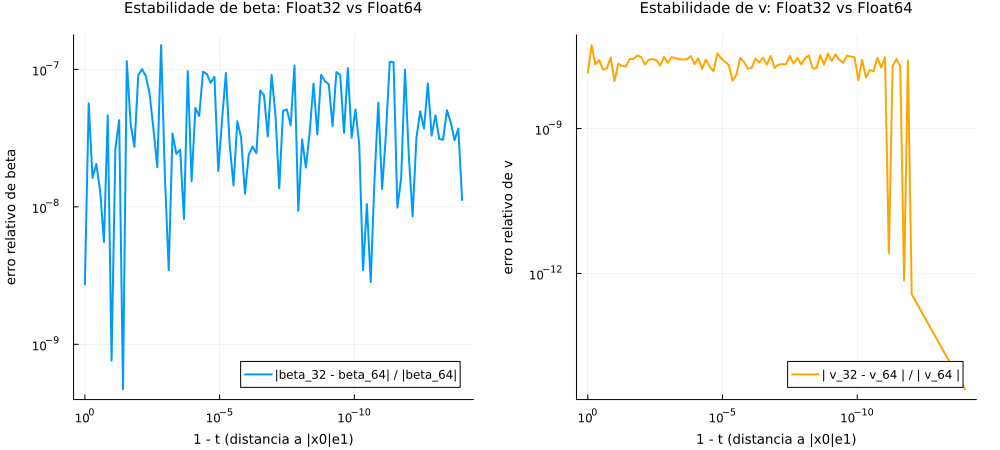

In [140]:
# Testando função
x0 = [10000.0, 6400.0, 4900.0, 8100.0, 2500.0, 3600.0, 4000.0, 1600.0]
xs, ts = calc_trajetory(x0, 100)
results = compute_vbeta(xs, Float32, Float64)

p1 = plot_betas(ts, results)
p2 = plot_vs(ts, results)
plot(p1, p2, layout=(1,2), size=(1000, 450))

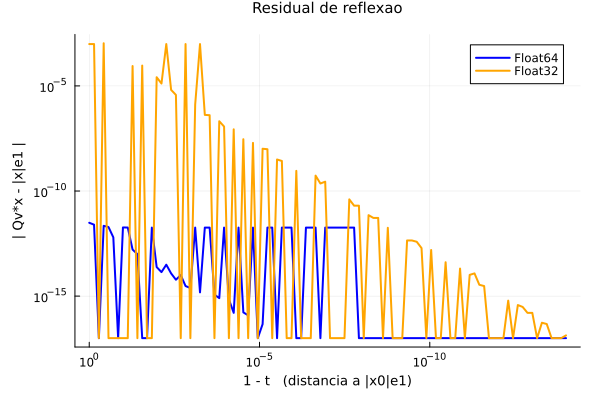

In [141]:
p3 = plot_residuals(ts, results)

### Discussão dos resultados

Os gráficos mostram o comportamento de $v$, $\beta$ e do resíduo de reflexão ao longo de uma trajetória $x(t) \to \|x_0\|e_1$. O eixo horizontal representa $1-t$: valores à direita correspondem ao caso crítico ($x \approx \|x_0\|e_1$).

**Erros relativos de $\beta$ e $v$:** ambos não apresentam tendência clara em nenhum dos tipos, consequência direta das fórmulas estáveis utilizadas em `reflector`, que evitam a subtração $x_1 - \|x\|$ substituindo-a por expressões equivalentes sem cancelamento. Float32 e Float64 concordam ao longo de toda a trajetória.

**Resíduo de reflexão:** mesmo com $v$ e $\beta$ calculados estavelmente, a *aplicação* $Q_v x = x - \beta(v^\top x)v$ reintroduz cancelamento catastrófico quando $x \approx \|x_0\|e_1$. O resíduo em Float32 cresce, enquanto o Float64 permanece próximo do epsilon de máquina. A oscilação em ambas as curvas é esperada e não compromete a interpretação.

**Conclusão:** a estabilidade de `reflector` resolve o problema no *cálculo* de $v$ e $\beta$, mas a limitação de precisão do Float32 se manifesta inevitavelmente na *aplicação* do refletor quando $x$ está quase alinhado com $e_1$.


---

## <a id="item-f"></a> Item f)

**Enunciado:** Escreva uma função `calc_beta(v)` que calcula $\beta$ unicamente a partir de $v$. Repita os testes `Float64` e `Float32` usando esta função, e compare os resultados com a função anterior. Observe que não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$, mesmo com $x$ quase alinhado com $e_1$.

**Solução:**  

Tínhamos visto em aula que os refletores de Householder $Q_v$ eram definidos da seguinte forma:

$$Q_v = I - 2\frac{vv^*}{v^*v}.$$

Porém, aqui o enunciado define refletores de uma forma diferente, com um $\beta$ genérico. Então, depois de conversar com alguns colegas de turma, o Angel me falou que essa era a forma para um **refletor genérico**, não necessariamente de Householder. Com isso, tentei provar por algumas longas horas que, ao fixar o resultado $Q_v(x) = \|x\|e_1$ (o refletor que satisfaz isso é um refletor de Householder), temos necessariamente que

$$\beta = \frac{2}{v^* v}.$$

E eu consegui.

> **Observação:** Vou mostrar a prova na ordem inversa, como alguns autores fazem para parecerem geniais. ;-)

### Prova de que $\beta = 2/(v^*v)$

Sabemos que (vide item a):

$$v = (v_1, v_2, \ldots, v_n)^\top = (x_1 - \|x\|,\; x_2,\; \ldots,\; x_n)^\top.$$

**Passo 1.** Vamos mostrar que $v$ é ortogonal a $(v - 2x)$, ou seja, que $v^*(v - 2x) = 0$.

Calculamos $v - 2x$ diretamente:

$$v - 2x = (x_1 - \|x\| - 2x_1,\; x_2 - 2x_2,\; \ldots,\; x_n - 2x_n)^\top = (-x_1 - \|x\|,\; -x_2,\; \ldots,\; -x_n)^\top.$$

Portanto:

$$v^*(v - 2x) = (x_1 - \|x\|)(-x_1 - \|x\|) + (-x_2^2) + \cdots + (-x_n^2).$$

O primeiro termo é uma diferença de quadrados:

$$(x_1 - \|x\|)(-x_1 - \|x\|) = -(x_1 - \|x\|)(x_1 + \|x\|) = -(x_1^2 - \|x\|^2) = \|x\|^2 - x_1^2.$$

Logo:

$$v^*(v - 2x) = \|x\|^2 - x_1^2 - x_2^2 - \cdots - x_n^2 = \|x\|^2 - \|x\|^2 = 0. \quad \checkmark$$

> **Observação:** Estamos supondo em todas essas manipulações que $x_1$ é puramente real, se ele tiver parte imaginária diferente de 0 o resultado é diferente.

**Passo 2.** Extraímos a relação algébrica útil desse resultado:

$$v^*(v - 2x) = 0 \;\implies\; v^*v - 2v^*x = 0 \;\implies\; v^*v = 2\,v^*x \;\implies\; \frac{1}{v^*x} = \frac{2}{v^*v}.$$

**Passo 3.** Voltamos à definição do refletor genérico. Por definição, $Q_v(x) = x - \beta(v^*x)v$. Fixando $Q_v(x) = \|x\|e_1$:

$$x - \beta(v^*x)v = \|x\|e_1 \;\implies\; x - \|x\|e_1 = \beta(v^*x)v.$$

Como provamos no item (a), $v = x - \|x\|e_1$, portanto a equação acima se reduz a:

$$v = \beta(v^*x)v.$$

Como $v \neq 0$, isso exige $\beta(v^*x) = 1$, ou seja:

$$\beta = \frac{1}{v^*x}.$$

Usando o resultado do Passo 2:

$$\beta = \frac{1}{v^*x} = \frac{2}{v^*v}$$



O **magnífico** truque visto anteriormente tem exatamente o objetivo de facilitar a escrita de `calc_beta(v)`: em vez de precisar de $x$ para calcular $\beta$, basta $v$, e a fórmula $\beta = 2/(v^*v)$ envolve apenas um produto interno e uma divisão.


É importante ressaltar que, como o cálculo envolve apenas produto interno e uma divisão, a função é *backwards stable*: o produto interno é backward stable (como visto em sala), e a divisão por um escalar não introduz instabilidade adicional.


In [ ]:
# Função para calcular beta diretamente de v
function calc_beta(v::AbstractVector{T}) where {T<:AbstractFloat}
    return 2 / dot(v, v)
end


# Repetindo testes feitos no item e
x_f32 = Float32[10^10, 0, 0, 0, 1]
x_f64 = Float64[10^10, 0, 0, 0, 1]

# v's e b's da função reflector
v_f32, b_f32 = reflector(x_f32)
v_f64, b_f64 = reflector(x_f64)

# Novos b's da função calc_beta(v)  
new_b_f32 = calc_beta(v_f32)
new_b_f64 = calc_beta(v_f64)


# Check dos tipos de cada elemento
println("Visualizando os Tipos")
println("Float32 -> b antigo: $(typeof(b_f32)), b novo: $(typeof(new_b_f32))")
println("Float64 -> b antigo: $(typeof(b_f64)), b novo: $(typeof(new_b_f64))")

# Check dos valores numéricos (teste de sanidade)
println()
println("Visualizando os valores numericos")
println("Float32 -> b antigo (reflector): $b_f32, b novo (calc_beta): $new_b_f32, |diferenca| = $(abs(b_f32 - new_b_f32))")
println("Float64 -> b antigo (reflector): $b_f64, b novo (calc_beta): $new_b_f64, |diferenca| = $(abs(b_f64 - new_b_f64))")


Visualizando os Tipos
Float32 -> b antigo: Float32, b novo: Float32
Float64 -> b antigo: Float64, b novo: Float64

Visualizando os valores numericos
Float32 -> b antigo (reflector): 2.0, b novo (calc_beta): 2.0, |diferenca| = 0.0
Float64 -> b antigo (reflector): 2.0, b novo (calc_beta): 2.0, |diferenca| = 0.0


In [134]:
function plot_betas_comparison(ts, results) # Função para comparar o jeito de calcular os betas
    diff_old = max.(abs.([r.beta_A_old for r in results] .- 
                         [r.beta_B_old for r in results]) ./ 
                    abs.([r.beta_B_old for r in results]), EPSILON)


    diff_new = max.(abs.([r.beta_A for r in results] .- 
                         [r.beta_B for r in results]) ./ 
                    abs.([r.beta_B for r in results]), EPSILON)
                    

    plot(1 .- ts, [diff_old diff_new],
        xscale=:log10, yscale=:log10,
        xflip=true,
        xlabel="1 - t (distancia a |x0|e1)",
        ylabel="erro relativo de beta",
        label=["reflector (antigo)" "calc_beta (novo)"],
        title="Comparacao: beta via reflector vs calc_beta",
        lw=2, color=[:blue :orange], legend=:bottomright,
        titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8,
        margin=3mm)

end

plot_betas_comparison (generic function with 1 method)

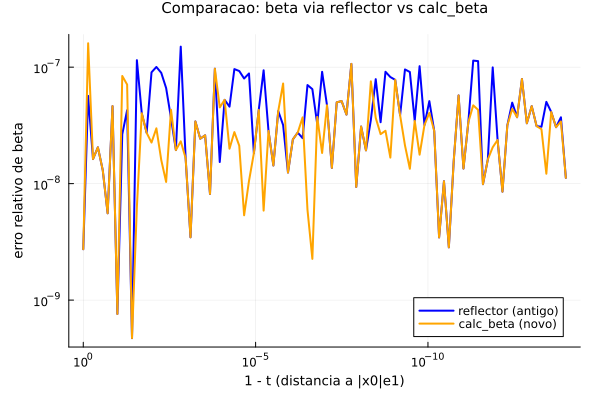

In [135]:
x0 = [10000.0, 6400.0, 4900.0, 8100.0, 2500.0, 3600.0, 4000.0, 1600.0]
xs, ts = calc_trajetory(x0, 100)
results_f = compute_vbeta(xs, Float32, Float64, use_calc_beta=true)
plot_betas_comparison(ts, results_f)

### Análise do resultado

Podemos observar que `calc_beta(v)` também é estável **porque recebe um $v$ já bem calculado**. A estabilidade não vem de `calc_beta` em si, vem do fato de que sua implementação de `reflector` calcula $v$ corretamente. Se você passasse um $v$ calculado ingenuamente (com $v_1 = x_1 - \|x\|$ direto), aí sim `calc_beta` produziria um $\beta$ ruim, mas o erro estaria em $v$, não em $\beta$.

### Alinhamento com o enunciado

Relembrando o que o enunciado diz a respeito dessa questão

"Observe que não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$, mesmo com $x$ quase alinhado com $e_1$".

E o gráfico confirma de uma forma empírica isso para nós.

---

## <a id="item-g"></a> Item g) (Bônus)

**Enunciado:** Mostre/Verifique que $v_1$ é (relativamente!) mal-condicionado quando $x$ está quase alinhado com $e_1$. Inspirado na fórmula para $\beta$, proponha outra fórmula para calcular $v_1$ (ainda refletindo $x$ em $\|x\| e_1$) que não seja tão sensível a $x_1$.

**Solução:**

### O problema: cancelamento ao calcular $v_1$

Pela fórmula "ingênua" do item (a), $v_1 = x_1 - \|x\|$. Quando $x_1 > 0$ e $x$ está quase alinhado com $e_1$ (ou seja, $\|y\| \ll x_1$), temos $x_1 \approx \|x\|$, e essa subtração sofre cancelamento catastrófico, exatamente o mesmo fenômeno discutido no item (b) para $\beta$.

### Conciliando com o item (d): mal-condicionado em que sentido?

No item (d) mostramos que o condicionamento absoluto de $v$ (o vetor inteiro) é $\hat{\kappa}(v) = \|J_v(x)\| \leq 2$. Isso parece, à primeira vista, dizer que $v$, e portanto $v_1$, é *bem*-condicionado. Não há contradição, mas sim uma distinção importante entre condicionamento absoluto e relativo:

$$\kappa_{\text{rel}}(v_1) \;\approx\; \kappa_{\text{abs}}(v_1) \cdot \frac{\|x\|}{|v_1|}.$$

- $\kappa_{\text{abs}}(v_1) \leq \hat{\kappa}(v) \leq 2$: uma perturbação absoluta $\delta$ em $x$ produz uma perturbação absoluta em $v_1$ de tamanho no máximo $2\|\delta\|$. Isso vale sempre, mesmo perto de $x \approx \|x\|e_1$.
- Porém, quando $x \to \|x\|e_1^{+}$ (ou seja, $x_1 \to \|x\|$), temos $v_1 = x_1 - \|x\| \to 0$, enquanto $\|x\|$ permanece $O(1)$. Logo $\|x\|/|v_1| \to \infty$, e $\kappa_{\text{rel}}(v_1) \to \infty$.

Em palavras: erros de arredondamento de tamanho $O(\varepsilon_{\text{máquina}}\cdot\|x\|)$ são *inevitáveis* em qualquer cálculo envolvendo $x$ (esse é o "piso" de erro absoluto, consistente com $\kappa_{\text{abs}}\le 2$). Mas, se o valor verdadeiro $|v_1|$ é muito menor do que esse piso, o erro relativo em $v_1$ explode, podendo chegar a $100\%$ ou mais (o resultado calculado pode até ter o sinal errado, ou ser identicamente $0$ quando o valor verdadeiro não é). Esse é precisamente o efeito do cancelamento catastrófico de $x_1 - \|x\|$ quando $x_1 \approx \|x\|$.

### Fórmula estável para $v_1$

A ideia é a mesma do item (b): reescrever $v_1$ sem nenhuma subtração entre quantidades próximas. Multiplicando $v_1 = x_1 - \|x\|$ por $\dfrac{x_1+\|x\|}{x_1+\|x\|}$:

$$v_1 = x_1 - \|x\| = \frac{x_1^2 - \|x\|^2}{x_1 + \|x\|} = \frac{-\|y\|^2}{\|x\| + x_1} = -\frac{\|y\|^2}{\|x\|+x_1}, \qquad y = (x_2,\dots,x_n).$$

Quando $x_1 > 0$, o denominador $\|x\| + x_1$ é uma soma de dois números positivos (sem cancelamento), e o numerador $\|y\|^2$ é uma soma de quadrados (também sem cancelamento). Logo essa expressão calcula $v_1$ de forma estável, mesmo quando $v_1 \to 0$, diferentemente da subtração direta, cujo erro absoluto não diminui quando o resultado verdadeiro diminui.

> **Observação:** esta é exatamente a fórmula já usada no ramo $x_1 > 0$ da função `reflector` do item (c)! Ou seja, a implementação do item (c) já incorpora a correção pedida aqui, o objetivo desta seção é tornar essa escolha explícita e verificar empiricamente seu efeito sobre $v_1$, isolando-o do restante de $v$ e de $\beta$.

### Verificação numérica

Vamos comparar, ao longo da mesma trajetória $x(t) \to \|x_0\|e_1$ usada no item (e) (com $x_1 > 0$ fixo em $x_0$), o erro relativo entre Float32 e Float64 de:

1. $v_1^{\text{ingênuo}} = x_1 - \|x\|$ (subtração direta);
2. $v_1^{\text{estável}} = -\|y\|^2/(\|x\|+x_1)$ (fórmula reescrita).

Se a análise acima estiver correta, esperamos que $v_1^{\text{ingênuo}}$ apresente erro relativo crescendo para $O(1)$ conforme $1-t \to 0$ (o resultado perde *todos* os dígitos significativos), enquanto $v_1^{\text{estável}}$ permaneça próximo do épsilon de máquina, como no item (e).

In [136]:
# v1 calculado de forma "ingênua": subtração direta, sujeita a cancelamento quando x1 > 0
v1_naive(x) = x[1] - sqrt(dot(x, x))

# v1 calculado de forma estável: -||y||^2 / (||x|| + x1), sem subtrações entre números próximos
function v1_stable(x)
    norm2y = dot(@view(x[2:end]), @view(x[2:end]))
    normx  = sqrt(norm2y + x[1]^2)
    return -norm2y / (normx + x[1])
end

v1_stable (generic function with 1 method)

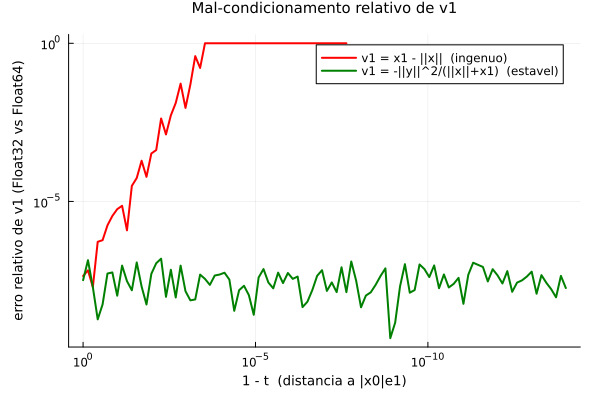

In [143]:
# Reaproveitamos a trajetória x(t) -> ||x0||e1 construída no item (e)

function compute_v1(xs)
    map(xs) do x
        xA, xB = Float32.(x), Float64.(x)
        (naive_A  = Float64(v1_naive(xA)),  naive_B  = Float64(v1_naive(xB)),
         stable_A = Float64(v1_stable(xA)), stable_B = Float64(v1_stable(xB)))
    end
end

function plot_v1_conditioning(ts, results)
    err_naive  = max.(abs.([r.naive_A  - r.naive_B  for r in results]) ./ abs.([r.naive_B  for r in results]),  EPSILON)
    err_stable = max.(abs.([r.stable_A - r.stable_B for r in results]) ./ abs.([r.stable_B for r in results]), EPSILON)

    plot(1 .- ts, [err_naive err_stable],
        xscale=:log10, yscale=:log10,
        xflip=true,
        xlabel="1 - t  (distancia a |x0|e1)",
        ylabel="erro relativo de v1 (Float32 vs Float64)",
        label=["v1 = x1 - ||x||  (ingenuo)" "v1 = -||y||^2/(||x||+x1)  (estavel)"],
        title="Mal-condicionamento relativo de v1",
        lw=2, color=[:red :green], legend=:topright,
        titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8,
        margin=3mm)

end

x0 = [10000.0, 6400.0, 4900.0, 8100.0, 2500.0, 3600.0, 4000.0, 1600.0]
xs, ts = calc_trajetory(x0, 100)
results_v1 = compute_v1(xs)
plot_v1_conditioning(ts, results_v1)    

### Discussão dos resultados

O gráfico mostra, mais uma vez, o erro relativo entre o resultado em Float32 e em Float64, ao longo da trajetória $x(t)\to\|x_0\|e_1$ (eixo horizontal: $1-t$, com o caso crítico à direita).

- **$v_1$ ingênuo ($x_1-\|x\|$):** conforme $1-t\to 0$, o valor verdadeiro de $v_1$ tende a $0$, mas o erro de arredondamento ao calcular a subtração $x_1-\|x\|$ permanece de tamanho $O(\varepsilon\cdot\|x\|)$, um piso de erro absoluto que não acompanha a queda de $|v_1|$. O erro **relativo** $|v_1^{(32)}-v_1^{(64)}|/|v_1^{(64)}|$ portanto cresce até $O(1)$: em algum ponto, o valor calculado em Float32 perde *todos* os algarismos significativos (podendo até zerar, enquanto o valor "verdadeiro" em Float64 ainda é não-nulo).
- **$v_1$ estável ($-\|y\|^2/(\|x\|+x_1)$):** como não há nenhuma subtração de quantidades próximas, o erro relativo permanece próximo do épsilon de máquina (Float32 $\approx 10^{-7}$) em toda a trajetória, mesmo quando $|v_1|\to 0$.

**Conclusão:** isso confirma a análise teórica: $v_1$ é *absolutamente* bem-condicionado (item d, $\hat\kappa\le 2$), mas pode ser *relativamente* mal-condicionado quando calculado por subtração direta, pois o erro absoluto inevitável (proporcional a $\|x\|$) não diminui junto com o valor verdadeiro de $v_1$ (que pode ficar arbitrariamente pequeno). A fórmula reescrita $-\|y\|^2/(\|x\|+x_1)$, a mesma já usada na implementação de `reflector` no item (c), resolve esse problema ao eliminar a subtração da computação.

